In [1]:
import argparse
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bigfish.stack as stack

In [2]:
root_path = Path("/data/smfish/20260311_bartelle_smFISH_cryo_48hr_male")

In [3]:
results_dir = (
        root_path
        / "big_fish"
        / "results"
        / "all_tiles_2D"
    )

# -------------------------------------------------------------------------
# Load segmentation to get ALL cell IDs
# -------------------------------------------------------------------------
cellpose_path = (
    root_path
    / "fused"
    / "fiducial_no_downsampling.ome_masks.tiff"
)

print("Loading segmentation...")
cell_label = stack.read_image(str(cellpose_path))

# Cellpose background = 0, so exclude it
cell_ids = np.unique(cell_label)
cell_ids = cell_ids[cell_ids != 0]

print(f"Total segmented cells: {len(cell_ids):,}")

Loading segmentation...
Total segmented cells: 4,554


In [4]:
# -------------------------------------------------------------------------
# Load spots from all 16 bits
# -------------------------------------------------------------------------
all_spots = []

for bit in range(1, 17):

    spots_path = results_dir / f"spots_bit_{bit}.csv"

    if not spots_path.exists():
        print(f"WARNING: {spots_path.name} not found. Skipping.")
        continue

    spots = pd.read_csv(spots_path)

    if "cell_id" not in spots.columns:
        raise ValueError(
            f"{spots_path.name} does not contain a cell_id column."
        )

    # Explicitly record bit number.
    # This avoids depending on how the bit_# column is formatted.
    spots["bit"] = bit

    all_spots.append(spots)

    print(f"Bit {bit:2d}: {len(spots):,} spots")

all_spots = pd.concat(all_spots, ignore_index=True)

print()
print(f"Total detected spots: {len(all_spots):,}")

Bit  1: 4,389 spots
Bit  2: 408,603 spots
Bit  3: 31,452 spots
Bit  4: 258,931 spots
Bit  5: 20,905 spots
Bit  6: 15,655 spots
Bit  7: 43,689 spots
Bit  8: 12,322 spots
Bit  9: 10,615 spots
Bit 10: 162,332 spots
Bit 11: 21,892 spots
Bit 12: 11,907 spots
Bit 13: 25,689 spots
Bit 14: 22,699 spots
Bit 15: 27,015 spots
Bit 16: 26,237 spots

Total detected spots: 1,104,332


In [5]:
# -------------------------------------------------------------------------
# Remove spots outside segmented cells
#
# cell_id == 0 means the spot falls outside a Cellpose mask.
# -------------------------------------------------------------------------
spots_in_cells = all_spots[all_spots["cell_id"] != 0].copy()

print(f"Spots inside cells:   {len(spots_in_cells):,}")
print(
    f"Spots outside cells:  "
    f"{len(all_spots) - len(spots_in_cells):,}"
)

# -------------------------------------------------------------------------
# Build cell-level table
# -------------------------------------------------------------------------
cell_stats = pd.DataFrame({
    "cell_id": cell_ids
})

# -------------------------------------------------------------------------
# 1. Total number of spots per cell across ALL bits
# -------------------------------------------------------------------------
spots_per_cell = (
    spots_in_cells
    .groupby("cell_id")
    .size()
    .rename("n_spots")
)

cell_stats = cell_stats.merge(
    spots_per_cell,
    left_on="cell_id",
    right_index=True,
    how="left",
)

cell_stats["n_spots"] = (
    cell_stats["n_spots"]
    .fillna(0)
    .astype(int)
)

Spots inside cells:   208,883
Spots outside cells:  895,449


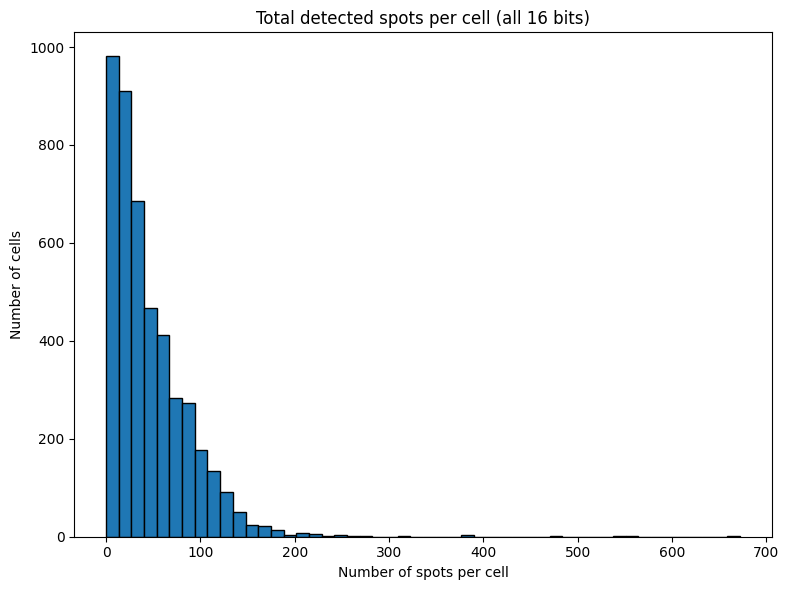

In [6]:
plt.figure(figsize=(8, 6))

plt.hist(
    cell_stats["n_spots"],
    bins=50,
    edgecolor="black",
)

plt.xlabel("Number of spots per cell")
plt.ylabel("Number of cells")
plt.title("Total detected spots per cell (all 16 bits)")

plt.tight_layout()

output_plot = results_dir / "histogram_spots_per_cell.png"

plt.savefig(
    output_plot,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [7]:
# -------------------------------------------------------------------------
# 2. Number of unique bits/genes detected per cell
# -------------------------------------------------------------------------
genes_per_cell = (
    spots_in_cells
    .groupby("cell_id")["bit"]
    .nunique()
    .rename("n_genes")
)

cell_stats = cell_stats.merge(
    genes_per_cell,
    left_on="cell_id",
    right_index=True,
    how="left",
)

cell_stats["n_genes"] = (
    cell_stats["n_genes"]
    .fillna(0)
    .astype(int)
)

# -------------------------------------------------------------------------
# Save cell-level statistics
# -------------------------------------------------------------------------
output_csv = results_dir / "cell_spot_statistics.csv"

cell_stats.to_csv(output_csv, index=False)

print()
print(f"Saved cell statistics to:")
print(f"  {output_csv}")

# -------------------------------------------------------------------------
# Summary
# -------------------------------------------------------------------------
print()
print("Cell-level summary")
print("------------------")
print(f"Cells:                  {len(cell_stats):,}")
print(f"Mean spots/cell:        {cell_stats['n_spots'].mean():.2f}")
print(f"Median spots/cell:      {cell_stats['n_spots'].median():.1f}")
print(f"Max spots/cell:         {cell_stats['n_spots'].max():,}")
print(f"Mean genes/cell:        {cell_stats['n_genes'].mean():.2f}")
print(f"Median genes/cell:      {cell_stats['n_genes'].median():.1f}")
print(f"Max genes/cell:         {cell_stats['n_genes'].max()}")



Saved cell statistics to:
  /data/smfish/20260311_bartelle_smFISH_cryo_48hr_male/big_fish/results/all_tiles_2D/cell_spot_statistics.csv

Cell-level summary
------------------
Cells:                  4,554
Mean spots/cell:        45.87
Median spots/cell:      34.0
Max spots/cell:         672
Mean genes/cell:        5.87
Median genes/cell:      6.0
Max genes/cell:         16


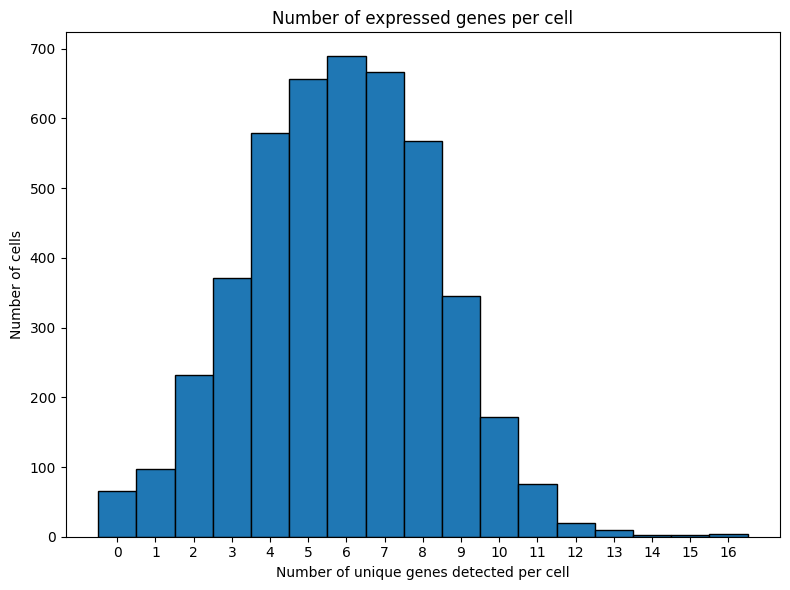

In [8]:
# =====================================================================
# HISTOGRAM 2
# Number of unique genes/bits per cell
#
# Since there are exactly 16 possible values, integer-centered bins
# make this histogram easier to interpret.
# =====================================================================

plt.figure(figsize=(8, 6))

bins = np.arange(-0.5, 17.5, 1)

plt.hist(
    cell_stats["n_genes"],
    bins=bins,
    edgecolor="black",
)

plt.xticks(range(17))

plt.xlabel("Number of unique genes detected per cell")
plt.ylabel("Number of cells")
plt.title("Number of expressed genes per cell")

plt.tight_layout()

output_plot = results_dir / "histogram_genes_per_cell.png"

plt.savefig(
    output_plot,
    dpi=300,
    bbox_inches="tight",
)

plt.show()